# CNN–Transformer: Deterministic vs MC Dropout Using the Same Checkpoint

This notebook performs an isolated inference comparison using the **exact original trained CNN–Transformer checkpoint**:

1. Deterministic inference with `model.predict()`.
2. Monte Carlo dropout inference with the same model and weights, using `training=True` for 100 stochastic passes.

There is no training call. The original `best_model.keras`, `feat_scaler.pkl`, and `target_scaler.pkl` are loaded from Google Drive. The notebook also registers the exact custom positional-encoding and Transformer-block classes required to deserialize the model.

Common protocol: lookback `96`, horizon `1`, chronological `80/10/10` split.

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Imports and reproducibility

In [5]:
import warnings
warnings.filterwarnings("ignore")

import hashlib
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf

# Exact common seed for the stochastic MC sequence
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# MC outputs are kept separate from the original deterministic artifacts
OUT_DIR = Path("outputs_cnn_transformer_same_checkpoint_mc")
OUT_DIR.mkdir(exist_ok=True)

print("Setup complete ✅")

Setup complete ✅


## Paths and common comparison configuration

In [8]:
# ── Exact dataset used by every comparison model
FILE_PATH     = "/content/drive/MyDrive/Colab Notebooks/electricity_demand_srilanka_fixed.csv"
TARGET_COL    = "Load Demand (kW)"
TIMESTAMP_COL = "Timestamp"

# ── Upload/copy the three ORIGINAL CNN-Transformer artifacts here
ARTIFACT_DIR       = Path("/content/drive/MyDrive/Colab Notebooks/cnn_transformer_baseline_artifacts")
MODEL_PATH         = ARTIFACT_DIR / "best_model.keras"
FEAT_SCALER_PATH   = ARTIFACT_DIR / "feat_scaler.pkl"
TARGET_SCALER_PATH = ARTIFACT_DIR / "target_scaler.pkl"

# ── Exact common sequence and chronological split configuration
LOOKBACK = 96
HORIZON  = 1
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# ── Shared training settings, documented for verification only
BATCH_SIZE = 128
MAX_EPOCHS = 50
LR         = 1e-3
DROPOUT_RATE = 0.20

# ── Expected CNN-Transformer architectural settings
D_MODEL        = 64
N_HEADS        = 4
D_FF           = 256
N_BLOCKS       = 3
LAYER_NORM_EPS = 1e-6

# ── MC-inference-only settings. Smaller chunks protect GPU memory because
# attention memory grows quadratically with the sequence length.
MC_SAMPLES       = 100
MC_BATCH_SIZE    = 32
MC_CHUNK_SIZE    = 5
ALPHA            = 0.05
RUN_MC_ON_TRAIN  = False  # Val/Test are sufficient; True is valid but much slower

assert np.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0)
assert D_MODEL % N_HEADS == 0

required_files = [MODEL_PATH, FEAT_SCALER_PATH, TARGET_SCALER_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Missing original CNN-Transformer artifact(s):\n  - "
        + "\n  - ".join(missing_files)
        + "\nUpload them to ARTIFACT_DIR, then rerun this cell."
    )

print("Original CNN-Transformer model and scaler artifacts found ✅")

Original CNN-Transformer model and scaler artifacts found ✅


## Load the exact same dataset

In [9]:
# ── Load CSV and parse timestamps
df = pd.read_csv(FILE_PATH, parse_dates=[TIMESTAMP_COL])
df = df.sort_values(TIMESTAMP_COL).reset_index(drop=True)
df = df.set_index(TIMESTAMP_COL)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df.index[0]}  →  {df.index[-1]}")
df.head(3)

Dataset shape : (189888, 16)
Date range    : 2020-01-01 00:00:00  →  2025-05-31 23:45:00


,Unnamed: 0,Temperature (°C),Humidity (%),Wind Speed (m/s),Rainfall (mm),Solar Irradiance (W/m²),GDP (LKR),Per Capita Energy Use (kWh),Electricity Price (LKR/kWh),Day of Week,Hour of Day,Month,Season,Public Event,Load Demand (kW),Poya Day
Timestamp,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,0,28.993428,75.011269,1.053861,4.140513,185.892561,925.621430,502.915605,20.454440,2,0,1,Summer,0,1202.4797,0
2020-01-01 00:15:00,1,27.723471,77.024015,1.085152,9.446997,281.782650,1020.823521,497.286366,27.776449,2,0,1,Summer,0,1213.1439,0
2020-01-01 00:30:00,2,29.295377,74.732958,3.363800,4.265813,328.942058,1028.847455,488.816292,21.097420,2,0,1,Summer,0,1215.3267,0


## Exact same feature engineering

In [10]:
# ── Cyclic encoding for hour, day-of-week, and month
# Using sin/cos so that e.g. hour 23 and hour 0 are "close" to each other
df["sin_hour"]  = np.sin(2 * np.pi * df["Hour of Day"] / 24)
df["cos_hour"]  = np.cos(2 * np.pi * df["Hour of Day"] / 24)
df["sin_dow"]   = np.sin(2 * np.pi * df["Day of Week"] / 7)
df["cos_dow"]   = np.cos(2 * np.pi * df["Day of Week"] / 7)
df["sin_month"] = np.sin(2 * np.pi * df["Month"] / 12)
df["cos_month"] = np.cos(2 * np.pi * df["Month"] / 12)

# ── Binary weekend flag
df["is_weekend"] = (df["Day of Week"] >= 5).astype(int)

# ── Normalized year (trend signal: 0.0 = 2022, 1.0 = 2025)
df["year_norm"] = (df.index.year - 2022) / 3

# ── Lag features — all shifted ≥ 96 steps (24h) to prevent data leakage
df["load_lag_96"]  = df[TARGET_COL].shift(96)       # 24 hours ago
df["load_lag_192"] = df[TARGET_COL].shift(192)      # 48 hours ago
df["load_lag_672"] = df[TARGET_COL].shift(96 * 7)  # 1 week ago

# ── Rolling statistics anchored at 24h ago (no leakage)
df["load_mean_week"] = df[TARGET_COL].shift(96).rolling(96 * 7).mean()  # 7-day mean
df["load_std_day"]   = df[TARGET_COL].shift(96).rolling(96).std()       # 24h std

# ── Drop rows with NaN (from lag/rolling windows)
df.dropna(inplace=True)
print(f"Rows after dropna: {len(df):,}")

Rows after dropna: 189,121


In [11]:
# ── Define final feature list
FEATURE_COLS = [
    # Weather inputs
    "Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)",
    "Rainfall (mm)", "Solar Irradiance (W/m²)",
    # Time features
    "sin_hour", "cos_hour", "sin_dow", "cos_dow",
    "sin_month", "cos_month", "is_weekend", "year_norm",
    # Calendar events
    "Public Event", "Poya Day",
    # Lag / rolling features
    "load_lag_96", "load_lag_192", "load_lag_672",
    "load_mean_week", "load_std_day",
]

# Keep only columns that actually exist in the dataframe
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

print(f"Total features : {len(FEATURE_COLS)}")
print(f"Feature list   : {FEATURE_COLS}")

Total features : 20
Feature list   : ['Temperature (°C)', 'Humidity (%)', 'Wind Speed (m/s)', 'Rainfall (mm)', 'Solar Irradiance (W/m²)', 'sin_hour', 'cos_hour', 'sin_dow', 'cos_dow', 'sin_month', 'cos_month', 'is_weekend', 'year_norm', 'Public Event', 'Poya Day', 'load_lag_96', 'load_lag_192', 'load_lag_672', 'load_mean_week', 'load_std_day']


## Leakage sanity check

In [12]:
print(f"{'Feature':<35}  Correlation with Target")
print("-" * 60)

for col in FEATURE_COLS:
    corr = df[col].corr(df[TARGET_COL])
    flag = "  ⚠️  POTENTIAL LEAKAGE" if abs(corr) > 0.98 else ""
    print(f"  {col:<35} {corr:+.4f}{flag}")

Feature                              Correlation with Target
------------------------------------------------------------
  Temperature (°C)                    +0.0132
  Humidity (%)                        +0.0015
  Wind Speed (m/s)                    +0.0016
  Rainfall (mm)                       -0.0024
  Solar Irradiance (W/m²)             -0.0044
  sin_hour                            +0.0636
  cos_hour                            -0.6127
  sin_dow                             +0.1589
  cos_dow                             -0.1787
  sin_month                           +0.2942
  cos_month                           -0.0485
  is_weekend                          -0.2134
  year_norm                           +0.6628
  Public Event                        -0.0642
  Poya Day                            -0.1162
  load_lag_96                         +0.9139
  load_lag_192                        +0.8584
  load_lag_672                        +0.9505
  load_mean_week                      +0.6981
  lo

## Exact same temporal split

In [13]:
n       = len(df)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)

# ── Chronological split
df_train = df.iloc[:n_train]
df_val   = df.iloc[n_train : n_train + n_val]
df_test  = df.iloc[n_train + n_val :]

print(f"Train : {len(df_train):,} samples  ({df_train.index[0].date()} → {df_train.index[-1].date()})")
print(f"Val   : {len(df_val):,} samples  ({df_val.index[0].date()} → {df_val.index[-1].date()})")
print(f"Test  : {len(df_test):,} samples  ({df_test.index[0].date()} → {df_test.index[-1].date()})")

Train : 151,296 samples  (2020-01-08 → 2024-05-02)
Val   : 18,912 samples  (2024-05-02 → 2024-11-15)
Test  : 18,913 samples  (2024-11-15 → 2025-05-31)


In [14]:
# ── Load the ORIGINAL fitted scalers; do not fit new scalers here
feat_scaler   = joblib.load(FEAT_SCALER_PATH)
target_scaler = joblib.load(TARGET_SCALER_PATH)

if getattr(feat_scaler, "n_features_in_", len(FEATURE_COLS)) != len(FEATURE_COLS):
    raise ValueError(
        f"Feature mismatch: scaler expects {feat_scaler.n_features_in_} features, "
        f"but this pipeline produced {len(FEATURE_COLS)}."
    )

X_tr_raw = feat_scaler.transform(df_train[FEATURE_COLS])
y_tr_raw = target_scaler.transform(df_train[[TARGET_COL]])

X_vl_raw = feat_scaler.transform(df_val[FEATURE_COLS])
y_vl_raw = target_scaler.transform(df_val[[TARGET_COL]])

X_te_raw = feat_scaler.transform(df_test[FEATURE_COLS])
y_te_raw = target_scaler.transform(df_test[[TARGET_COL]])

print("Original fitted scalers loaded and applied ✅")

Original fitted scalers loaded and applied ✅


## Exact same sliding-window sequences

In [15]:
def build_sequences(X, y, lookback, horizon=1):
    """
    Convert flat arrays into overlapping windows.
    X shape: (samples, lookback, features)
    y shape: (samples, horizon)
    """
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon + 1):
        Xs.append(X[i : i + lookback])
        ys.append(y[i + lookback : i + lookback + horizon, 0])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


X_tr, y_tr = build_sequences(X_tr_raw, y_tr_raw, LOOKBACK, HORIZON)
X_vl, y_vl = build_sequences(X_vl_raw, y_vl_raw, LOOKBACK, HORIZON)
X_te, y_te = build_sequences(X_te_raw, y_te_raw, LOOKBACK, HORIZON)

print(f"Train  X: {X_tr.shape}  y: {y_tr.shape}")
print(f"Val    X: {X_vl.shape}  y: {y_vl.shape}")
print(f"Test   X: {X_te.shape}  y: {y_te.shape}")

# ── Quick check: make sure target is not constant
assert y_tr.std() > 0.01, "❌ Target variance near zero — check sequence building!"
print(f"\nTarget stats — mean: {y_tr.mean():.4f}  std: {y_tr.std():.4f}  ✅")

Train  X: (151200, 96, 20)  y: (151200, 1)
Val    X: (18816, 96, 20)  y: (18816, 1)
Test   X: (18817, 96, 20)  y: (18817, 1)

Target stats — mean: 0.0003  std: 1.0001  ✅


## Register custom layers, load and verify the checkpoint

The corrected CNN–Transformer contains serializable custom `PositionalEncoding` and `TransformerBlock` layers. Their definitions must be registered before loading the `.keras` file. The validation checks prevent a checkpoint with the wrong input shape, horizon, CNN filters, Transformer dimensions, block count, or dropout rate from being used silently.

In [16]:
CUSTOM_LAYER_MODULE_SOURCE = r'''import numpy as np
import tensorflow as tf


@tf.keras.utils.register_keras_serializable(package="LoadForecasting")
class PositionalEncoding(tf.keras.layers.Layer):
    """Fixed sinusoidal positional encoding for temporal order."""

    def __init__(self, max_seq_len, d_model, **kwargs):
        super().__init__(**kwargs)
        self.max_seq_len = int(max_seq_len)
        self.d_model = int(d_model)

        position = np.arange(self.max_seq_len, dtype=np.float32)[:, np.newaxis]
        dimension = np.arange(self.d_model, dtype=np.float32)[np.newaxis, :]
        angle_rates = 1.0 / np.power(
            10000.0, (2 * np.floor(dimension / 2)) / self.d_model
        )
        angles = position * angle_rates

        encoding = np.zeros((self.max_seq_len, self.d_model), dtype=np.float32)
        encoding[:, 0::2] = np.sin(angles[:, 0::2])
        encoding[:, 1::2] = np.cos(angles[:, 1::2])
        self.positional_encoding = tf.constant(encoding[np.newaxis, :, :])

    def call(self, inputs):
        sequence_length = tf.shape(inputs)[1]
        encoding = tf.cast(
            self.positional_encoding[:, :sequence_length, :], inputs.dtype
        )
        return inputs + encoding

    def get_config(self):
        config = super().get_config()
        config.update({
            "max_seq_len": self.max_seq_len,
            "d_model": self.d_model,
        })
        return config


@tf.keras.utils.register_keras_serializable(package="LoadForecasting")
class TransformerBlock(tf.keras.layers.Layer):
    """Transformer encoder with attention and feed-forward residuals."""

    def __init__(
        self, d_model, n_heads, d_ff, dropout_rate,
        layer_norm_eps=1e-6, **kwargs
    ):
        super().__init__(**kwargs)
        self.d_model = int(d_model)
        self.n_heads = int(n_heads)
        self.d_ff = int(d_ff)
        self.dropout_rate = float(dropout_rate)
        self.layer_norm_eps = float(layer_norm_eps)

        self.attention = tf.keras.layers.MultiHeadAttention(
            num_heads=self.n_heads,
            key_dim=self.d_model // self.n_heads,
            dropout=self.dropout_rate,
        )
        self.attention_dropout = tf.keras.layers.Dropout(self.dropout_rate)
        self.attention_norm = tf.keras.layers.LayerNormalization(
            epsilon=self.layer_norm_eps
        )

        self.ffn_dense_1 = tf.keras.layers.Dense(self.d_ff, activation="relu")
        self.ffn_dense_2 = tf.keras.layers.Dense(self.d_model)
        self.ffn_dropout = tf.keras.layers.Dropout(self.dropout_rate)
        self.ffn_norm = tf.keras.layers.LayerNormalization(
            epsilon=self.layer_norm_eps
        )

    def call(self, inputs, training=None):
        attention_output = self.attention(inputs, inputs, training=training)
        attention_output = self.attention_dropout(
            attention_output, training=training
        )
        x = self.attention_norm(inputs + attention_output)

        ffn_output = self.ffn_dense_2(self.ffn_dense_1(x))
        ffn_output = self.ffn_dropout(ffn_output, training=training)
        return self.ffn_norm(x + ffn_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model": self.d_model,
            "n_heads": self.n_heads,
            "d_ff": self.d_ff,
            "dropout_rate": self.dropout_rate,
            "layer_norm_eps": self.layer_norm_eps,
        })
        return config
'''

# Register the classes in this runtime and retain the same source for deployment.
exec(CUSTOM_LAYER_MODULE_SOURCE, globals())


def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


custom_objects = {
    "PositionalEncoding": PositionalEncoding,
    "TransformerBlock": TransformerBlock,
    "LoadForecasting>PositionalEncoding": PositionalEncoding,
    "LoadForecasting>TransformerBlock": TransformerBlock,
}

model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects=custom_objects,
    compile=False,
)
checkpoint_sha256 = sha256_file(MODEL_PATH)

# ── Data-interface checks
expected_input_shape = (LOOKBACK, len(FEATURE_COLS))
actual_input_shape = tuple(model.input_shape[1:])
actual_output_units = int(model.output_shape[-1])
if actual_input_shape != expected_input_shape:
    raise ValueError(
        f"Checkpoint input mismatch: expected {expected_input_shape}, "
        f"found {actual_input_shape}."
    )
if actual_output_units != HORIZON:
    raise ValueError(
        f"Checkpoint horizon mismatch: expected {HORIZON}, "
        f"found {actual_output_units}."
    )

# ── Architecture checks
conv_layers = [
    layer for layer in model.layers
    if isinstance(layer, tf.keras.layers.Conv1D)
]
if [layer.filters for layer in conv_layers] != [64, 32]:
    raise ValueError(
        f"Expected Conv1D filters [64, 32], found "
        f"{[layer.filters for layer in conv_layers]}."
    )

transformer_blocks = [
    layer for layer in model.layers
    if isinstance(layer, TransformerBlock)
]
if len(transformer_blocks) != N_BLOCKS:
    raise ValueError(
        f"Expected {N_BLOCKS} Transformer blocks, "
        f"found {len(transformer_blocks)}."
    )

for index, block in enumerate(transformer_blocks, start=1):
    observed = (
        block.d_model, block.n_heads, block.d_ff,
        block.dropout_rate, block.layer_norm_eps,
    )
    expected = (D_MODEL, N_HEADS, D_FF, DROPOUT_RATE, LAYER_NORM_EPS)
    if not (
        observed[:3] == expected[:3]
        and np.isclose(observed[3], expected[3])
        and np.isclose(observed[4], expected[4])
    ):
        raise ValueError(
            f"Transformer block {index} mismatch: expected {expected}, "
            f"found {observed}."
        )

top_level_dropout = [
    layer for layer in model.layers
    if isinstance(layer, tf.keras.layers.Dropout)
]
if len(top_level_dropout) != 1 or not np.isclose(
    float(top_level_dropout[0].rate), DROPOUT_RATE
):
    raise ValueError(
        "Expected one top-level output Dropout(0.20) in the corrected "
        "CNN-Transformer checkpoint."
    )

print(f"Checkpoint loaded: {MODEL_PATH}")
print(f"SHA-256: {checkpoint_sha256}")
print(f"Input shape: {model.input_shape}")
print(f"Output shape: {model.output_shape}")
print(f"Parameters: {model.count_params():,}")
print(f"Transformer blocks: {len(transformer_blocks)}")
print("Dropout is available in attention, feed-forward, and output paths ✅")
model.summary()

Checkpoint loaded: /content/drive/MyDrive/Colab Notebooks/cnn_transformer_baseline_artifacts/best_model.keras
SHA-256: 1329594c91b596d8b93d0b0a41987e94f24ef47afbb2dbf97606914cb3c6cc92
Input shape: (None, 96, 20)
Output shape: (None, 1)
Parameters: 166,369
Transformer blocks: 3
Dropout is available in attention, feed-forward, and output paths ✅


Model: "CNN_Transformer_Forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 96, 20)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 96, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 96, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 96, 64)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 96, 64)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 96, 64)         │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 96, 64)         │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ (None, 96, 64)         │        49,984 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_dropout (Dropout)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_output (Dense)         │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,369 (649.88 KB)

 Trainable params: 166,369 (649.88 KB)

 Non-trainable params: 0 (0.00 B)

## No training in this notebook

The checkpoint already contains the learned weights from the original CNN–Transformer run. Skipping retraining ensures deterministic and MC-dropout predictions differ only because of inference behavior.

In [17]:
# Deliberately no training call.
print("Using the original trained CNN-Transformer checkpoint — no retraining performed ✅")

Using the original trained CNN-Transformer checkpoint — no retraining performed ✅


## Deterministic evaluation of the original checkpoint

These metrics should match the original CNN–Transformer results apart from negligible numerical differences. A mismatch means the wrong checkpoint, scalers, dataset, feature order, or split was loaded and must be fixed before using the MC results.

In [18]:
def metric_values(y_true, y_pred):
    return {
        "MAE_kW": float(mean_absolute_error(y_true, y_pred)),
        "RMSE_kW": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE_pct": float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100),
        "R2": float(r2_score(y_true, y_pred)),
    }


def print_metric_line(split_name, metrics):
    print(
        f"  {split_name:6s} → MAE={metrics['MAE_kW']:.2f} kW | "
        f"RMSE={metrics['RMSE_kW']:.2f} kW | "
        f"MAPE={metrics['MAPE_pct']:.2f}% | R²={metrics['R2']:.4f}"
    )


def evaluate_deterministic(X, y_scaled, split_name):
    pred_scaled = model.predict(X, batch_size=BATCH_SIZE, verbose=0)
    y_true = target_scaler.inverse_transform(y_scaled)
    y_pred = target_scaler.inverse_transform(pred_scaled)
    metrics = metric_values(y_true, y_pred)
    print_metric_line(split_name, metrics)
    return y_true, y_pred, metrics


print("── Deterministic Evaluation Results ──")
y_tr_true, y_tr_pred, det_train_metrics = evaluate_deterministic(X_tr, y_tr, "Train")
y_vl_true, y_vl_pred, det_val_metrics   = evaluate_deterministic(X_vl, y_vl, "Val")
y_te_true, y_te_pred, det_test_metrics  = evaluate_deterministic(X_te, y_te, "Test")

── Deterministic Evaluation Results ──
  Train  → MAE=34.54 kW | RMSE=45.44 kW | MAPE=1.98% | R²=0.9784
  Val    → MAE=40.39 kW | RMSE=50.70 kW | MAPE=1.95% | R²=0.9532
  Test   → MAE=38.80 kW | RMSE=46.38 kW | MAPE=1.76% | R²=0.9357


## Monte Carlo dropout inference

Calling the loaded model with `training=True` activates the dropout already present inside every Transformer attention/feed-forward block and in the output head. No layer or weight is changed. Chunked execution reduces GPU-memory pressure without changing the 100-sample estimator.

In [19]:
def mc_predict(model, X, n_samples=MC_SAMPLES, batch_size=MC_BATCH_SIZE,
               mc_chunk_size=MC_CHUNK_SIZE):
    """Return MC predictive mean and std in scaled target space."""
    if n_samples < 2:
        raise ValueError("MC_SAMPLES must be at least 2.")

    mean_parts, std_parts = [], []
    dataset = tf.data.Dataset.from_tensor_slices(X).batch(batch_size)

    for batch in dataset:
        batch_n = int(tf.shape(batch)[0])
        pred_sum = np.zeros((batch_n, HORIZON), dtype=np.float64)
        pred_sq_sum = np.zeros((batch_n, HORIZON), dtype=np.float64)
        completed = 0

        while completed < n_samples:
            current_chunk = min(mc_chunk_size, n_samples - completed)

            # Each row is repeated current_chunk times. Independent dropout masks
            # are generated for those repeated copies because training=True.
            repeated_batch = tf.repeat(batch, repeats=current_chunk, axis=0)
            chunk_pred = model(repeated_batch, training=True).numpy()
            chunk_pred = chunk_pred.reshape(batch_n, current_chunk, HORIZON)

            pred_sum += chunk_pred.sum(axis=1)
            pred_sq_sum += np.square(chunk_pred).sum(axis=1)
            completed += current_chunk

        batch_mean = pred_sum / n_samples
        batch_var = np.maximum(pred_sq_sum / n_samples - np.square(batch_mean), 0.0)
        mean_parts.append(batch_mean.astype(np.float32))
        std_parts.append(np.sqrt(batch_var).astype(np.float32))

    return np.concatenate(mean_parts, axis=0), np.concatenate(std_parts, axis=0)


def evaluate_mc(X, y_scaled, split_name):
    mean_scaled, std_scaled = mc_predict(model, X)

    y_true = target_scaler.inverse_transform(y_scaled)
    y_mean = target_scaler.inverse_transform(mean_scaled)
    y_std = std_scaled * target_scaler.scale_[0]
    metrics = metric_values(y_true, y_mean)

    print_metric_line(split_name, metrics)
    return y_true, y_mean, y_std, metrics

In [20]:
# Val and Test are always evaluated with the MC mean because they are the
# official model-selection and held-out comparison splits.
print(f"Running {MC_SAMPLES} MC forward passes per input...")
print("── MC-Dropout Mean Evaluation Results ──")

if RUN_MC_ON_TRAIN:
    y_tr_mc_true, y_tr_mean, y_tr_std, mc_train_metrics = evaluate_mc(X_tr, y_tr, "Train")
else:
    y_tr_mean = y_tr_std = mc_train_metrics = None
    print("  Train  → skipped (set RUN_MC_ON_TRAIN=True if required; this does not affect Val/Test)")

y_vl_mc_true, y_vl_mean, y_vl_std, mc_val_metrics = evaluate_mc(X_vl, y_vl, "Val")
y_te_mc_true, y_te_mean, y_te_std, mc_test_metrics = evaluate_mc(X_te, y_te, "Test")

Running 100 MC forward passes per input...
── MC-Dropout Mean Evaluation Results ──
  Train  → skipped (set RUN_MC_ON_TRAIN=True if required; this does not affect Val/Test)
  Val    → MAE=18.92 kW | RMSE=30.21 kW | MAPE=0.97% | R²=0.9834
  Test   → MAE=20.46 kW | RMSE=29.23 kW | MAPE=0.97% | R²=0.9745


## Test per-step breakdown

In [21]:
print("── MC Test Per-Step Breakdown ──")
print(f"{'Step':<10}{'MAE':>10}{'RMSE':>10}{'MAPE':>11}{'R²':>10}")
print("-" * 51)

per_step_metrics = {}
for h in range(HORIZON):
    values = metric_values(y_te_mc_true[:, h], y_te_mean[:, h])
    per_step_metrics[f"step_{h + 1}"] = values
    print(
        f"Step {h + 1:<5}{values['MAE_kW']:>10.2f}{values['RMSE_kW']:>10.2f}"
        f"{values['MAPE_pct']:>10.2f}%{values['R2']:>10.4f}"
    )

print("-" * 51)
print(
    f"{'Overall':<10}{mc_test_metrics['MAE_kW']:>10.2f}{mc_test_metrics['RMSE_kW']:>10.2f}"
    f"{mc_test_metrics['MAPE_pct']:>10.2f}%{mc_test_metrics['R2']:>10.4f}"
)

── MC Test Per-Step Breakdown ──
Step             MAE      RMSE       MAPE        R²
---------------------------------------------------
Step 1         20.46     29.23      0.97%    0.9745
---------------------------------------------------
Overall        20.46     29.23      0.97%    0.9745


## Supplementary uncertainty calibration

Raw MC intervals (`mean ± 1.96 × MC std`) describe dropout-based epistemic spread. A validation-residual quantile is reported as an empirical calibration layer and applied unchanged to the test set.

Because the same validation split was used for early stopping in the original training—as required by the common protocol—the calibrated interval is supplementary rather than a strict independent split-conformal guarantee.

In [22]:
def interval_stats(y_true, lower, upper):
    coverage = float(np.mean((y_true >= lower) & (y_true <= upper)) * 100)
    width = float(np.mean(upper - lower))
    return {"coverage_pct": coverage, "mean_width_kW": width}


# Raw dropout intervals
y_vl_raw_lo = y_vl_mean - 1.96 * y_vl_std
y_vl_raw_hi = y_vl_mean + 1.96 * y_vl_std
y_te_raw_lo = y_te_mean - 1.96 * y_te_std
y_te_raw_hi = y_te_mean + 1.96 * y_te_std

raw_val_stats = interval_stats(y_vl_mc_true, y_vl_raw_lo, y_vl_raw_hi)
raw_test_stats = interval_stats(y_te_mc_true, y_te_raw_lo, y_te_raw_hi)

# Finite-sample corrected validation residual quantile
calibration_residuals = np.abs(y_vl_mc_true - y_vl_mean).ravel()
n_cal = len(calibration_residuals)
quantile_level = min(np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal, 1.0)
try:
    q_hat = float(np.quantile(calibration_residuals, quantile_level, method="higher"))
except TypeError:  # compatibility with older NumPy
    q_hat = float(np.quantile(calibration_residuals, quantile_level, interpolation="higher"))

y_vl_cal_lo, y_vl_cal_hi = y_vl_mean - q_hat, y_vl_mean + q_hat
y_te_cal_lo, y_te_cal_hi = y_te_mean - q_hat, y_te_mean + q_hat

cal_val_stats = interval_stats(y_vl_mc_true, y_vl_cal_lo, y_vl_cal_hi)
cal_test_stats = interval_stats(y_te_mc_true, y_te_cal_lo, y_te_cal_hi)

print("── Supplementary Uncertainty Results ──")
print(f"Mean MC std — Val={y_vl_std.mean():.2f} kW | Test={y_te_std.mean():.2f} kW")
print(f"Raw 95% MC interval — Val coverage={raw_val_stats['coverage_pct']:.2f}% | Test coverage={raw_test_stats['coverage_pct']:.2f}%")
print(f"Validation residual radius q_hat={q_hat:.2f} kW")
print(f"Calibrated interval — Val coverage={cal_val_stats['coverage_pct']:.2f}% | Test coverage={cal_test_stats['coverage_pct']:.2f}%")

── Supplementary Uncertainty Results ──
Mean MC std — Val=29.82 kW | Test=40.18 kW
Raw 95% MC interval — Val coverage=85.88% | Test coverage=90.83%
Validation residual radius q_hat=72.05 kW
Calibrated interval — Val coverage=95.01% | Test coverage=97.12%


## Save checkpoint identity, metrics, and predictions

In [23]:
results = {
    "model": "CNN-Transformer deterministic vs MC Dropout — same checkpoint",
    "checkpoint": {
        "path": str(MODEL_PATH),
        "sha256": checkpoint_sha256,
        "parameters": int(model.count_params()),
        "trained_in_this_notebook": False,
    },
    "comparison_protocol": {
        "lookback": LOOKBACK,
        "horizon": HORIZON,
        "train_val_test": [TRAIN_RATIO, VAL_RATIO, TEST_RATIO],
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "learning_rate": LR,
        "dropout": DROPOUT_RATE,
        "optimizer": "Adam",
        "loss": "MAE",
        "early_stopping_patience": 15,
        "reduce_lr_patience": 8,
        "seed": SEED,
        "shuffle": False,
    },
    "architecture": {
        "d_model": D_MODEL,
        "attention_heads": N_HEADS,
        "feed_forward_units": D_FF,
        "transformer_blocks": N_BLOCKS,
    },
    "mc_inference": {
        "samples": MC_SAMPLES,
        "point_estimator": "MC predictive mean",
        "same_checkpoint_as_deterministic": True,
    },
    "deterministic_checkpoint": {
        "train": det_train_metrics,
        "val": det_val_metrics,
        "test": det_test_metrics,
    },
    "mc_mean": {
        "train": mc_train_metrics,
        "val": mc_val_metrics,
        "test": mc_test_metrics,
        "test_per_step": per_step_metrics,
    },
    "uncertainty_supplementary": {
        "alpha": ALPHA,
        "mean_mc_std_val_kW": float(y_vl_std.mean()),
        "mean_mc_std_test_kW": float(y_te_std.mean()),
        "raw_mc_val": raw_val_stats,
        "raw_mc_test": raw_test_stats,
        "validation_residual_q_hat_kW": q_hat,
        "calibrated_val": cal_val_stats,
        "calibrated_test": cal_test_stats,
        "note": "Validation was also used for early stopping; calibrated coverage is supplementary, not strict split-conformal coverage.",
    },
}

with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump(results, f, indent=2)

# Long-format export preserves every configured forecast horizon
records = []
for sample_i in range(len(y_te_mc_true)):
    for horizon_i in range(HORIZON):
        target_position = LOOKBACK + sample_i + horizon_i
        records.append({
            "sample": sample_i,
            "horizon_step": horizon_i + 1,
            "target_timestamp": df_test.index[target_position],
            "actual_kW": y_te_mc_true[sample_i, horizon_i],
            "mc_mean_kW": y_te_mean[sample_i, horizon_i],
            "mc_std_kW": y_te_std[sample_i, horizon_i],
            "raw_mc_lower_kW": y_te_raw_lo[sample_i, horizon_i],
            "raw_mc_upper_kW": y_te_raw_hi[sample_i, horizon_i],
            "calibrated_lower_kW": y_te_cal_lo[sample_i, horizon_i],
            "calibrated_upper_kW": y_te_cal_hi[sample_i, horizon_i],
        })

pd.DataFrame.from_records(records).to_csv(
    OUT_DIR / "cnn_transformer_mc_predictions.csv", index=False
)

print(f"Metrics saved → {OUT_DIR / 'metrics.json'}")
print(f"Predictions saved → {OUT_DIR / 'cnn_transformer_mc_predictions.csv'}")

Metrics saved → outputs_cnn_transformer_same_checkpoint_mc/metrics.json
Predictions saved → outputs_cnn_transformer_same_checkpoint_mc/cnn_transformer_mc_predictions.csv


## Visual diagnostics

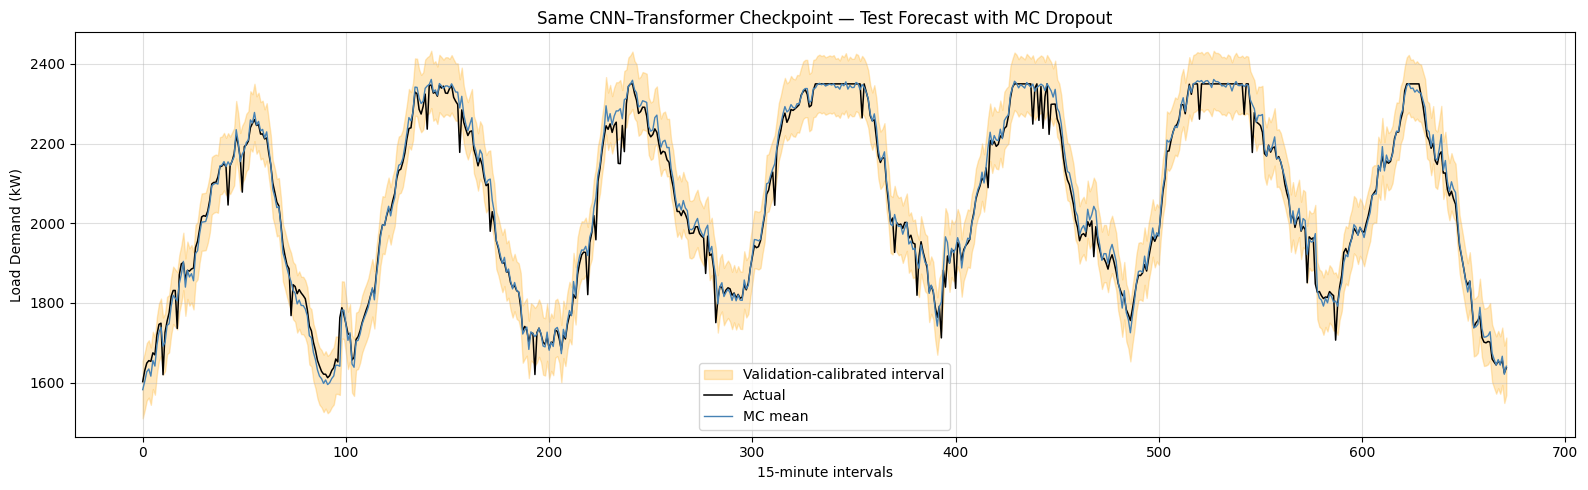

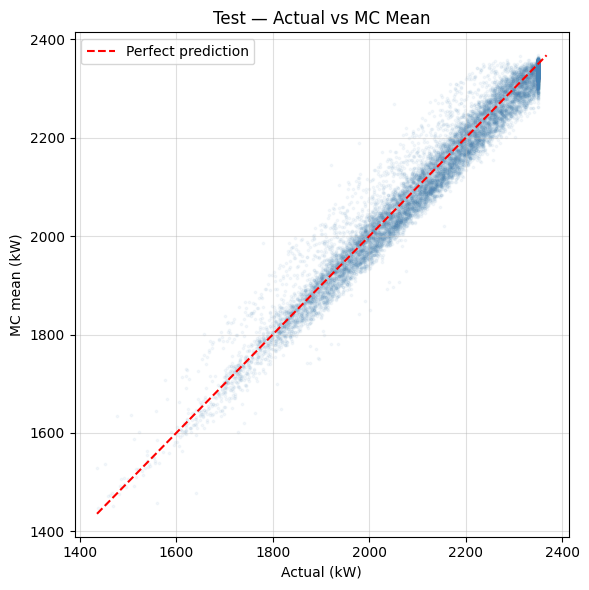

In [24]:
# First-horizon forecast with supplementary calibrated interval
n_plot = min(4 * 24 * 7, len(y_te_mc_true))
x_axis = np.arange(n_plot)
fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(
    x_axis, y_te_cal_lo[:n_plot, 0], y_te_cal_hi[:n_plot, 0],
    color="orange", alpha=0.25, label="Validation-calibrated interval"
)
ax.plot(x_axis, y_te_mc_true[:n_plot, 0], color="black", lw=1.1, label="Actual")
ax.plot(x_axis, y_te_mean[:n_plot, 0], color="steelblue", lw=1.0, label="MC mean")
ax.set_title("Same CNN–Transformer Checkpoint — Test Forecast with MC Dropout")
ax.set_xlabel("15-minute intervals")
ax.set_ylabel("Load Demand (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "cnn_transformer_same_checkpoint_mc_test_forecast.png", dpi=150)
plt.show()

# Actual vs MC mean
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_te_mc_true.ravel(), y_te_mean.ravel(), alpha=0.05, s=3, color="steelblue")
lims = [min(y_te_mc_true.min(), y_te_mean.min()), max(y_te_mc_true.max(), y_te_mean.max())]
ax.plot(lims, lims, "r--", lw=1.5, label="Perfect prediction")
ax.set_title("Test — Actual vs MC Mean")
ax.set_xlabel("Actual (kW)")
ax.set_ylabel("MC mean (kW)")
ax.legend()
ax.grid(True, alpha=0.4)
fig.tight_layout()
fig.savefig(OUT_DIR / "cnn_transformer_same_checkpoint_mc_scatter.png", dpi=150)
plt.show()

## Reporting guidance

- Report deterministic and MC-mean Test MAE, RMSE, MAPE, and R² as two inference variants of the **same CNN–Transformer checkpoint**.
- Confirm the deterministic metrics match the original CNN–Transformer run before accepting MC results.
- Report MC standard deviation and interval coverage separately as uncertainty results.
- Record the checkpoint SHA-256 in the research appendix.
- This notebook intentionally performs no training.

## Create the forecasting deployment bundle

This cell copies the original model and scalers, writes the required custom-layer module, records all preprocessing and uncertainty settings, creates a reusable MC-inference helper, and packages everything as a ZIP file in Google Drive.

In [25]:
DEPLOY_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/cnn_transformer_mc_deployment"
)
DEPLOY_DIR.mkdir(parents=True, exist_ok=True)

# Preserve the exact trained checkpoint and its original fitted scalers
shutil.copy2(MODEL_PATH, DEPLOY_DIR / "best_model.keras")
shutil.copy2(FEAT_SCALER_PATH, DEPLOY_DIR / "feat_scaler.pkl")
shutil.copy2(TARGET_SCALER_PATH, DEPLOY_DIR / "target_scaler.pkl")

# A CNN-Transformer .keras file requires these custom classes when reloaded.
(DEPLOY_DIR / "cnn_transformer_custom_layers.py").write_text(
    CUSTOM_LAYER_MODULE_SOURCE,
    encoding="utf-8",
)

deployment_config = {
    "model_name": "CNN-Transformer with MC Dropout Inference",
    "lookback": LOOKBACK,
    "horizon": HORIZON,
    "features": FEATURE_COLS,
    "target": TARGET_COL,
    "mc_samples": MC_SAMPLES,
    "dropout_rate": DROPOUT_RATE,
    "alpha": ALPHA,
    "q_hat_kW": float(q_hat),
    "checkpoint_sha256": checkpoint_sha256,
    "architecture": {
        "cnn_filters": [64, 32],
        "d_model": D_MODEL,
        "attention_heads": N_HEADS,
        "feed_forward_units": D_FF,
        "transformer_blocks": N_BLOCKS,
    },
}

with open(DEPLOY_DIR / "deployment_config.json", "w") as file:
    json.dump(deployment_config, file, indent=2)

MC_INFERENCE_MODULE_SOURCE = r'''import json
import sys
from pathlib import Path

import joblib
import numpy as np
import tensorflow as tf

MODULE_DIR = Path(__file__).resolve().parent
if str(MODULE_DIR) not in sys.path:
    sys.path.insert(0, str(MODULE_DIR))

from cnn_transformer_custom_layers import PositionalEncoding, TransformerBlock


class CNNTransformerMCDropoutForecaster:
    """Load the deployment bundle and produce deterministic or MC forecasts."""

    def __init__(self, bundle_dir=None):
        self.bundle_dir = Path(bundle_dir or MODULE_DIR)
        with open(self.bundle_dir / "deployment_config.json") as file:
            self.config = json.load(file)

        self.feature_scaler = joblib.load(self.bundle_dir / "feat_scaler.pkl")
        self.target_scaler = joblib.load(self.bundle_dir / "target_scaler.pkl")
        custom_objects = {
            "PositionalEncoding": PositionalEncoding,
            "TransformerBlock": TransformerBlock,
            "LoadForecasting>PositionalEncoding": PositionalEncoding,
            "LoadForecasting>TransformerBlock": TransformerBlock,
        }
        self.model = tf.keras.models.load_model(
            self.bundle_dir / "best_model.keras",
            custom_objects=custom_objects,
            compile=False,
        )

    def prepare_sequence(self, feature_frame):
        """Convert a 96-row feature DataFrame into model input shape (1,96,20)."""
        columns = self.config["features"]
        lookback = int(self.config["lookback"])
        if len(feature_frame) != lookback:
            raise ValueError(f"Expected {lookback} rows, received {len(feature_frame)}.")
        missing = [column for column in columns if column not in feature_frame.columns]
        if missing:
            raise ValueError(f"Missing feature columns: {missing}")
        scaled = self.feature_scaler.transform(feature_frame[columns])
        return scaled[np.newaxis, ...].astype(np.float32)

    def deterministic_forecast(self, feature_frame):
        X = self.prepare_sequence(feature_frame)
        scaled = self.model.predict(X, verbose=0)
        return float(self.target_scaler.inverse_transform(scaled)[0, 0])

    def mc_forecast(self, feature_frame, mc_samples=None):
        X = self.prepare_sequence(feature_frame)
        n_samples = int(mc_samples or self.config["mc_samples"])
        predictions = np.stack([
            self.model(X, training=True).numpy()
            for _ in range(n_samples)
        ], axis=0)

        mean_scaled = predictions.mean(axis=0)
        std_scaled = predictions.std(axis=0)
        mean_kW = float(self.target_scaler.inverse_transform(mean_scaled)[0, 0])
        std_kW = float(std_scaled[0, 0] * self.target_scaler.scale_[0])
        q_hat = float(self.config["q_hat_kW"])

        return {
            "forecast_kW": mean_kW,
            "mc_std_kW": std_kW,
            "calibrated_lower_kW": mean_kW - q_hat,
            "calibrated_upper_kW": mean_kW + q_hat,
            "mc_samples": n_samples,
        }
'''

(DEPLOY_DIR / "mc_inference.py").write_text(
    MC_INFERENCE_MODULE_SOURCE,
    encoding="utf-8",
)

archive_path = shutil.make_archive(
    str(DEPLOY_DIR),
    "zip",
    root_dir=DEPLOY_DIR,
)

print("Deployment bundle created ✅")
for path in sorted(DEPLOY_DIR.iterdir()):
    print(f"  {path.name}")
print(f"ZIP bundle → {archive_path}")

Deployment bundle created ✅
  best_model.keras
  cnn_transformer_custom_layers.py
  deployment_config.json
  feat_scaler.pkl
  mc_inference.py
  target_scaler.pkl
ZIP bundle → /content/drive/MyDrive/Colab Notebooks/cnn_transformer_mc_deployment.zip


In [26]:
repeat_results = []

for inference_seed in [42, 43, 44]:
    tf.random.set_seed(inference_seed)

    _, y_mean, y_std, metrics = evaluate_mc(
        X_te, y_te, f"Test seed {inference_seed}"
    )

    repeat_results.append({
        "seed": inference_seed,
        **metrics,
        "mean_mc_std_kW": float(y_std.mean())
    })

pd.DataFrame(repeat_results)

  Test seed 42 → MAE=20.42 kW | RMSE=29.17 kW | MAPE=0.97% | R²=0.9746
  Test seed 43 → MAE=20.37 kW | RMSE=29.18 kW | MAPE=0.96% | R²=0.9746
  Test seed 44 → MAE=20.39 kW | RMSE=29.17 kW | MAPE=0.96% | R²=0.9746


,seed,MAE_kW,RMSE_kW,MAPE_pct,R2,mean_mc_std_kW
0,42,20.415096,29.174714,0.965536,0.974574,40.204855
1,43,20.369978,29.175093,0.963680,0.974573,40.172377
2,44,20.393911,29.166067,0.964601,0.974589,40.181179


In [27]:
repeat_df = pd.DataFrame(repeat_results)

print("Mean results across MC repetitions:")
print(repeat_df.mean(numeric_only=True))

print("\nStandard deviation across repetitions:")
print(repeat_df.std(numeric_only=True))

Mean results across MC repetitions:
seed              43.000000
MAE_kW            20.392995
RMSE_kW           29.171958
MAPE_pct           0.964606
R2                 0.974579
mean_mc_std_kW    40.186137
dtype: float64

Standard deviation across repetitions:
seed              1.000000
MAE_kW            0.022573
RMSE_kW           0.005105
MAPE_pct          0.000928
R2                0.000009
mean_mc_std_kW    0.016797
dtype: float64
